# Maximal Marginal Relevance (MMR) と DPP のシミュレーション

このノートブックでは、同じ候補集合から **MMR** と **Determinantal Point Process (DPP)** を使って上位 $k$ 件を選び、
選択結果の違い（関連性と多様性のトレードオフ）を観察します。

- **MMR**: 貪欲法で「クエリ関連性」と「既選択との非類似性」をバランス
- **DPP**: 集合全体の多様性（行列式）を高くするように選択

可視化で、選ばれた点の散らばり方と平均関連度・平均類似度を比較します。

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from dpp import dpp_greedy_map, make_dpp_kernel
from mmr import mmr_select
from selection_export import export_selection_artifacts

# 再現性のため固定
RNG_SEED = 42
np.random.seed(RNG_SEED)

plt.style.use("seaborn-v0_8-whitegrid")

In [18]:
def make_synthetic_items(n_items: int = 60, dim: int = 2) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """2次元埋め込み・クエリ・関連度を作る。"""
    # クラスタを持つ候補点を作る
    centers = np.array([
        [2.2, 1.0],
        [-2.0, 1.5],
        [0.0, -2.2],
    ])
    cluster_ids = np.random.choice(len(centers), size=n_items, p=[0.45, 0.35, 0.20])
    x = centers[cluster_ids] + 0.75 * np.random.randn(n_items, dim)

    # クエリは右上方向に置く
    query = np.array([2.5, 1.5])

    # 関連度をクエリとのコサイン類似度で定義
    relevance = cosine_similarity(x, query.reshape(1, -1)).ravel()
    return x, query, relevance


def cosine_similarity_matrix(x: np.ndarray) -> np.ndarray:
    sim = cosine_similarity(x)
    np.fill_diagonal(sim, 1.0)
    return sim


def plot_selection(
    x: np.ndarray,
    query: np.ndarray,
    selected: list[int],
    title: str,
    relevance: np.ndarray,
    ax: plt.Axes | None = None,
) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(x[:, 0], x[:, 1], c=relevance, cmap="viridis", s=45, alpha=0.75, label="all items")

    if selected:
        s = np.array(selected)
        ax.scatter(
            x[s, 0],
            x[s, 1],
            facecolors="none",
            edgecolors="crimson",
            s=220,
            linewidths=2.0,
            label="selected",
        )
        for rank, idx in enumerate(selected, start=1):
            ax.text(x[idx, 0] + 0.05, x[idx, 1] + 0.05, str(rank), fontsize=9)

    ax.scatter(query[0], query[1], marker="*", s=300, c="black", label="query")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(loc="best")


x, query, relevance = make_synthetic_items()
sim = cosine_similarity_matrix(x)

print(f"items: {len(x)}")
print(f"relevance min/max: {relevance.min():.3f} / {relevance.max():.3f}")

items: 60
relevance min/max: -0.967 / 1.000


In [11]:
def avg_pairwise_similarity(sim: np.ndarray, selected: list[int]) -> float:
    if len(selected) < 2:
        return 0.0
    s = np.array(selected)
    sub = sim[np.ix_(s, s)]
    mask = ~np.eye(len(s), dtype=bool)
    return float(sub[mask].mean())


def report_metrics(name: str, selected: list[int], relevance: np.ndarray, sim: np.ndarray) -> None:
    mean_rel = float(np.mean(relevance[selected])) if selected else 0.0
    mean_sim = avg_pairwise_similarity(sim, selected)
    print(f"[{name}] k={len(selected)}")
    print(f"  mean relevance      : {mean_rel:.4f}")
    print(f"  mean pairwise sim   : {mean_sim:.4f} (低いほど多様)")

[MMR] k=10
  mean relevance      : 0.9880
  mean pairwise sim   : 0.9772 (低いほど多様)
[DPP] k=10
  mean relevance      : 0.9426
  mean pairwise sim   : 0.8975 (低いほど多様)


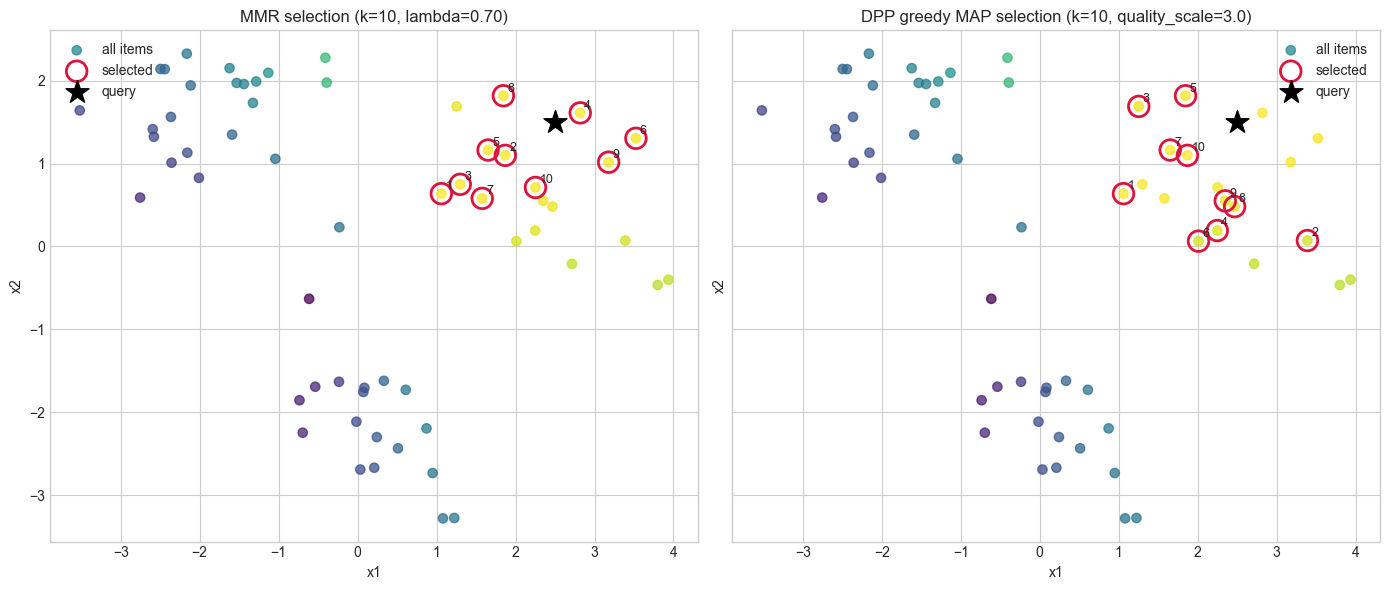

MMR selected indices: [21, 28, 16, 50, 9, 18, 44, 6, 51, 33]
DPP selected indices: [21, 35, 19, 7, 6, 26, 9, 41, 32, 28]


In [19]:
# パラメータ設定
k = 10
lambda_rel = 0.70      # MMR: 1.0 に近いほど関連度重視
quality_scale = 3.0    # DPP: 大きいほど関連度 (quality) の重みが強い

mmr_selected = mmr_select(relevance=relevance, sim=sim, k=k, lambda_rel=lambda_rel)
l_kernel = make_dpp_kernel(relevance=relevance, sim=sim, quality_scale=quality_scale)
dpp_selected = dpp_greedy_map(l=l_kernel, k=k)

report_metrics("MMR", mmr_selected, relevance, sim)
report_metrics("DPP", dpp_selected, relevance, sim)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

plot_selection(
    x=x,
    query=query,
    selected=mmr_selected,
    title=f"MMR selection (k={k}, lambda={lambda_rel:.2f})",
    relevance=relevance,
    ax=axes[0],
)

plot_selection(
    x=x,
    query=query,
    selected=dpp_selected,
    title=f"DPP greedy MAP selection (k={k}, quality_scale={quality_scale:.1f})",
    relevance=relevance,
    ax=axes[1],
)

fig.tight_layout()
plt.show()

print("MMR selected indices:", mmr_selected)
print("DPP selected indices:", dpp_selected)

In [13]:
# パラメータ感度の簡易比較
lambda_grid = [0.3, 0.5, 0.7, 0.9]
quality_grid = [1.5, 3.0, 5.0]

print("=== MMR (vary lambda) ===")
for lam in lambda_grid:
    sel = mmr_select(relevance, sim, k=k, lambda_rel=lam)
    report_metrics(f"MMR lambda={lam:.1f}", sel, relevance, sim)

print("\n=== DPP (vary quality_scale) ===")
for qs in quality_grid:
    l = make_dpp_kernel(relevance, sim, quality_scale=qs)
    sel = dpp_greedy_map(l, k=k)
    report_metrics(f"DPP quality_scale={qs:.1f}", sel, relevance, sim)

=== MMR (vary lambda) ===
[MMR lambda=0.3] k=10
  mean relevance      : 0.6225
  mean pairwise sim   : 0.3266 (低いほど多様)
[MMR lambda=0.5] k=10
  mean relevance      : 0.8465
  mean pairwise sim   : 0.7278 (低いほど多様)
[MMR lambda=0.7] k=10
  mean relevance      : 0.9961
  mean pairwise sim   : 0.9916 (低いほど多様)
[MMR lambda=0.9] k=10
  mean relevance      : 0.9961
  mean pairwise sim   : 0.9916 (低いほど多様)

=== DPP (vary quality_scale) ===
[DPP quality_scale=1.5] k=10
  mean relevance      : 0.9052
  mean pairwise sim   : 0.7997 (低いほど多様)
[DPP quality_scale=3.0] k=10
  mean relevance      : 0.9420
  mean pairwise sim   : 0.8808 (低いほど多様)
[DPP quality_scale=5.0] k=10
  mean relevance      : 0.9779
  mean pairwise sim   : 0.9515 (低いほど多様)


## 選択過程のアニメーション出力

`matplotlib` だけで、MMR/DPP の選択ステップを GIF として書き出せます。

- `outputs/selection_process.gif`: 選択過程のアニメーション

In [25]:
# スライド/GIF出力の実装は selection_export.py に分離
# main.ipynb では必要変数を定義して関数を呼ぶだけにする

In [29]:
import importlib
import selection_export

importlib.reload(selection_export)

gif_path, num_frames, mmr_selected_trace, dpp_selected_trace = selection_export.export_selection_artifacts(
    x=x,
    query=query,
    relevance=relevance,
    sim=sim,
    k=k,
    lambda_rel=lambda_rel,
    quality_scale=quality_scale,
    output_dir="outputs",
    gif_name="selection_process.gif",
    fps=1,
    interval_ms=900,
)

print(f"saved gif   : {gif_path}")
print(f"frames      : {num_frames}")
print("MMR selected indices (trace last):", mmr_selected_trace)
print("DPP selected indices (trace last):", dpp_selected_trace)

saved gif   : outputs/selection_process.gif
frames      : 10
MMR selected indices (trace last): [21, 28, 16, 50, 9, 18, 44, 6, 51, 33]
DPP selected indices (trace last): [21, 35, 19, 7, 6, 26, 9, 41, 32, 28]
